# ShopX Telemetry & Incident Postmortem Analysis (Assignment)

This notebook integrates **Exploratory Data Analysis (EDA)**, **Metrics Anomaly Detection**, and **Log Diagnostics** to troubleshoot the ShopX incident.
It satisfies the lab requirement for a reproducible code pipeline starting from raw data and follows the AIOps mindset.

## Table of Contents
1. **Part 1: Exploratory Data Analysis & Detailed Plotting**
   - Detailed plotting of each metrics CSV file (API Gateway, Cart, Order, Payment, Product Services)
   - Detailed plotting of log volumes and levels (Cart and Order Services)
2. **Part 2: Multi-Service Distribution & Normality Testing**
   - Shapiro-Wilk, Skewness, and Kurtosis across all 5 services' metrics
   - Grid of Histograms with Fitted Normal curves for each CSV
3. **Part 3: Multi-Service Anomaly Detection & Comparison**
   - 3-Sigma (Z-score) vs. Robust IQR comparison across all 5 CSV files
   - **Full anomaly detection plots for each CSV file** showing thresholds and earliest anomaly markers
4. **Part 4: Cart Service Feature Engineering & Isolation Forest**
   - Isolation Forest training & outlier detection
   - **Multi-Dimensional Anomaly Space Scatter Plot**
5. **Part 5: Log Diagnostics & Cascade Correlation**
   - Log Warnings and GC Overhead trends
   - **Telemetry Fusion plot**: Metrics JVM GC Pauses vs. Logs GC Warnings
   - Distributed Tracing context propagation test
   - **Domino Cascade Sequence Timeline Step Plot**
   - Chronological Cascade timeline reconstruction (Temporal Correlation)
6. **Part 6: Root Cause Analysis (RCA) & Remediation Plan**

# =========================================================================
# PART 1: EXPLORATORY DATA ANALYSIS & DETAILED PLOTTING
# =========================================================================

In [29]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Set up clean styling for premium visual reports
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13

# Custom colors
METRIC_COLORS = {
    'blue': '#3b82f6',
    'red': '#ef4444',
    'green': '#10b981',
    'orange': '#f59e0b',
    'purple': '#8b5cf6',
    'pink': '#ec4899',
    'cyan': '#06b6d4',
    'teal': '#14b8a6',
    'rose': '#f43f5e'
}

# Load all 5 metrics files
metrics_path = 'g2/metrics/'
api_df = pd.read_csv(os.path.join(metrics_path, 'api-gateway.csv'))
cart_df = pd.read_csv(os.path.join(metrics_path, 'cart-service.csv'))
order_df = pd.read_csv(os.path.join(metrics_path, 'order-service.csv'))
payment_df = pd.read_csv(os.path.join(metrics_path, 'payment-service.csv'))
product_df = pd.read_csv(os.path.join(metrics_path, 'product-service.csv'))

# Convert timestamps to datetime
for df in [api_df, cart_df, order_df, payment_df, product_df]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.sort_values('timestamp', inplace=True)

print("Loaded all telemetry data. Rows per service:")
print(f"  API Gateway    : {len(api_df)}")
print(f"  Cart Service   : {len(cart_df)}")
print(f"  Order Service  : {len(order_df)}")
print(f"  Payment Service: {len(payment_df)}")
print(f"  Product Service: {len(product_df)}")

Loaded all telemetry data. Rows per service:
  API Gateway    : 2820
  Cart Service   : 2820
  Order Service  : 2820
  Payment Service: 2820
  Product Service: 2820


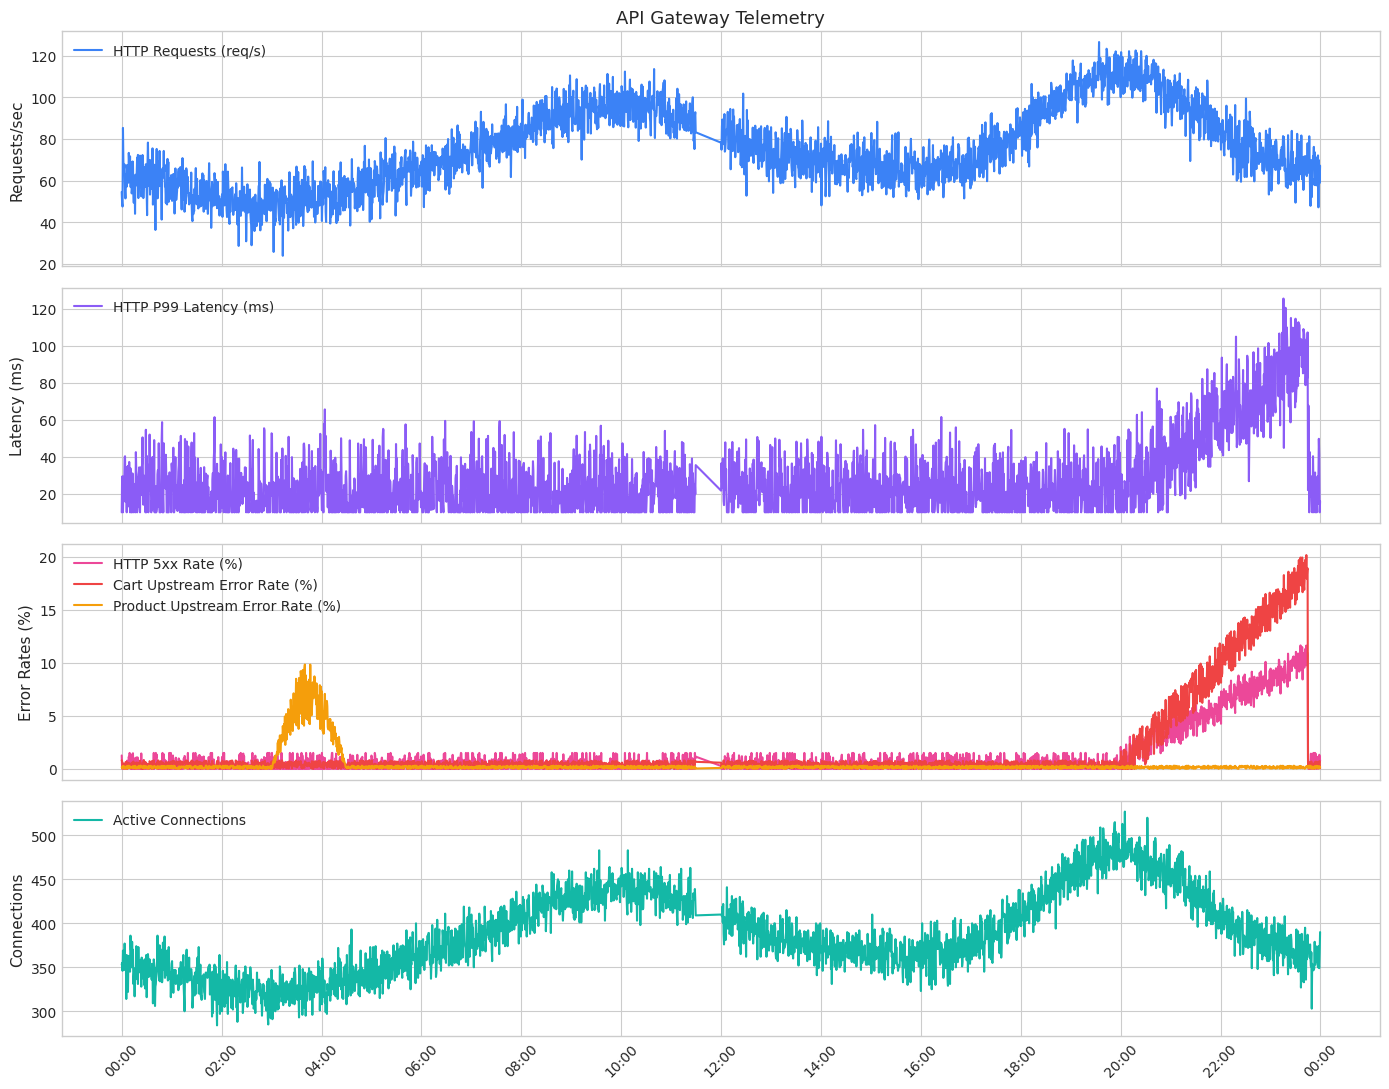

In [30]:
# 1. Plot API Gateway
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(api_df['timestamp'], api_df['http_requests_per_sec'], color=METRIC_COLORS['blue'], label='HTTP Requests (req/s)')
axes[0].set_ylabel('Requests/sec')
axes[0].legend(loc='upper left')
axes[0].set_title('API Gateway Telemetry')

axes[1].plot(api_df['timestamp'], api_df['http_p99_latency_ms'], color=METRIC_COLORS['purple'], label='HTTP P99 Latency (ms)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend(loc='upper left')

axes[2].plot(api_df['timestamp'], api_df['http_5xx_rate'], color=METRIC_COLORS['pink'], label='HTTP 5xx Rate (%)')
axes[2].plot(api_df['timestamp'], api_df['cart_upstream_error_rate'], color=METRIC_COLORS['red'], label='Cart Upstream Error Rate (%)')
axes[2].plot(api_df['timestamp'], api_df['product_upstream_error_rate'], color=METRIC_COLORS['orange'], label='Product Upstream Error Rate (%)')
axes[2].set_ylabel('Error Rates (%)')
axes[2].legend(loc='upper left')

axes[3].plot(api_df['timestamp'], api_df['active_connections'], color=METRIC_COLORS['teal'], label='Active Connections')
axes[3].set_ylabel('Connections')
axes[3].legend(loc='upper left')

axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

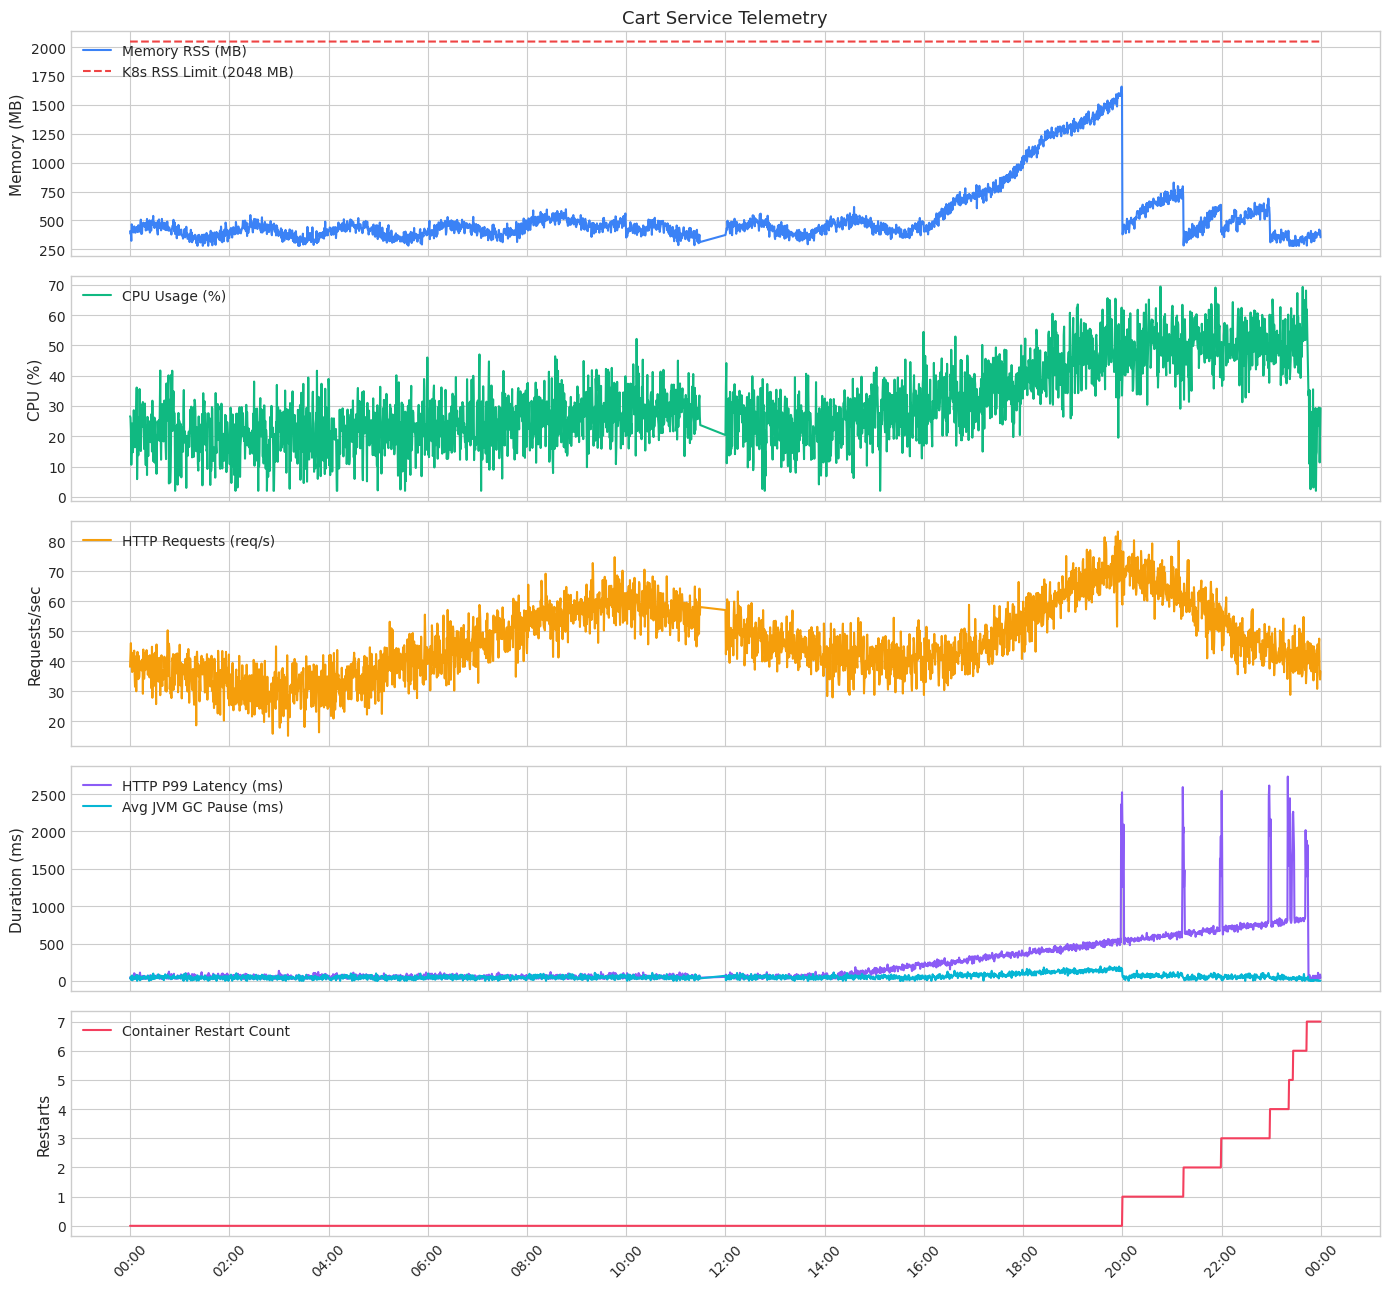

In [31]:
# 2. Plot Cart Service
fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)

axes[0].plot(cart_df['timestamp'], cart_df['memory_usage_bytes'] / (1024*1024), color=METRIC_COLORS['blue'], label='Memory RSS (MB)')
axes[0].plot(cart_df['timestamp'], cart_df['memory_limit_bytes'] / (1024*1024), color=METRIC_COLORS['red'], linestyle='--', label='K8s RSS Limit (2048 MB)')
axes[0].set_ylabel('Memory (MB)')
axes[0].legend(loc='upper left')
axes[0].set_title('Cart Service Telemetry')

axes[1].plot(cart_df['timestamp'], cart_df['cpu_usage_percent'], color=METRIC_COLORS['green'], label='CPU Usage (%)')
axes[1].set_ylabel('CPU (%)')
axes[1].legend(loc='upper left')

axes[2].plot(cart_df['timestamp'], cart_df['http_requests_per_sec'], color=METRIC_COLORS['orange'], label='HTTP Requests (req/s)')
axes[2].set_ylabel('Requests/sec')
axes[2].legend(loc='upper left')

axes[3].plot(cart_df['timestamp'], cart_df['http_p99_latency_ms'], color=METRIC_COLORS['purple'], label='HTTP P99 Latency (ms)')
axes[3].plot(cart_df['timestamp'], cart_df['jvm_gc_pause_ms_avg'], color=METRIC_COLORS['cyan'], label='Avg JVM GC Pause (ms)')
axes[3].set_ylabel('Duration (ms)')
axes[3].legend(loc='upper left')

axes[4].plot(cart_df['timestamp'], cart_df['container_restart_count'], color=METRIC_COLORS['rose'], label='Container Restart Count')
axes[4].set_ylabel('Restarts')
axes[4].legend(loc='upper left')

axes[4].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[4].xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

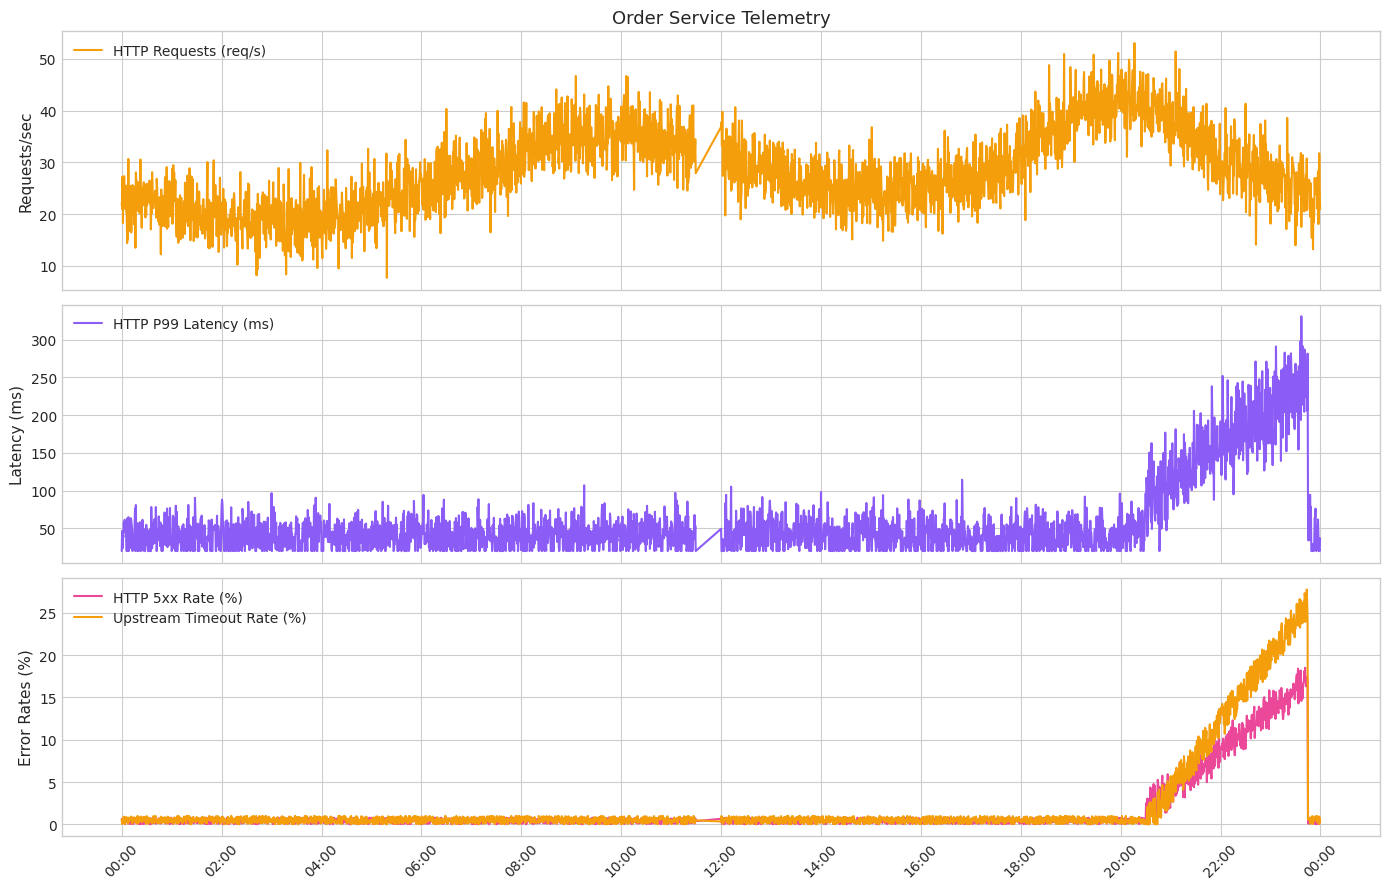

In [32]:
# 3. Plot Order Service
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(order_df['timestamp'], order_df['http_requests_per_sec'], color=METRIC_COLORS['orange'], label='HTTP Requests (req/s)')
axes[0].set_ylabel('Requests/sec')
axes[0].legend(loc='upper left')
axes[0].set_title('Order Service Telemetry')

axes[1].plot(order_df['timestamp'], order_df['http_p99_latency_ms'], color=METRIC_COLORS['purple'], label='HTTP P99 Latency (ms)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend(loc='upper left')

axes[2].plot(order_df['timestamp'], order_df['http_5xx_rate'], color=METRIC_COLORS['pink'], label='HTTP 5xx Rate (%)')
axes[2].plot(order_df['timestamp'], order_df['upstream_timeout_rate'], color=METRIC_COLORS['orange'], label='Upstream Timeout Rate (%)')
axes[2].set_ylabel('Error Rates (%)')
axes[2].legend(loc='upper left')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

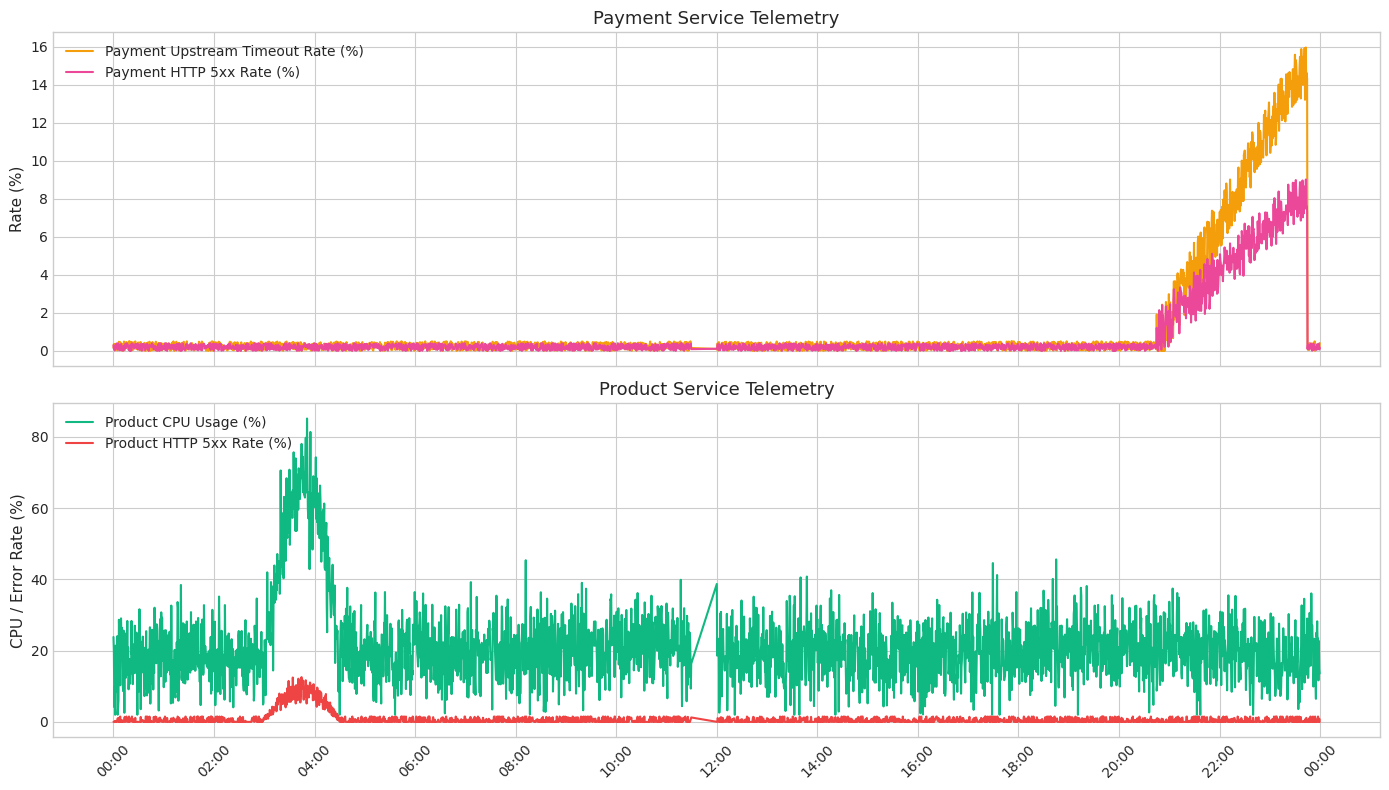

In [33]:
# 4. Plot Payment and Product Services
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Payment Service
ax1.plot(payment_df['timestamp'], payment_df['upstream_timeout_rate'], color=METRIC_COLORS['orange'], label='Payment Upstream Timeout Rate (%)')
ax1.plot(payment_df['timestamp'], payment_df['http_5xx_rate'], color=METRIC_COLORS['pink'], label='Payment HTTP 5xx Rate (%)')
ax1.set_ylabel('Rate (%)')
ax1.legend(loc='upper left')
ax1.set_title('Payment Service Telemetry')

# Product Service
ax2.plot(product_df['timestamp'], product_df['cpu_usage_percent'], color=METRIC_COLORS['green'], label='Product CPU Usage (%)')
ax2.plot(product_df['timestamp'], product_df['http_5xx_rate'], color=METRIC_COLORS['red'], label='Product HTTP 5xx Rate (%)')
ax2.set_ylabel('CPU / Error Rate (%)')
ax2.legend(loc='upper left')
ax2.set_title('Product Service Telemetry')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Helper to read logs and bin them by time window
def parse_and_bin_logs(log_path, bin_size='5min'):
    data = []
    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line)
                data.append({
                    'timestamp': pd.to_datetime(obj.get('timestamp')),
                    'level': obj.get('level', 'UNKNOWN')
                })
            except:
                pass
    df = pd.DataFrame(data)
    df = df.set_index('timestamp')
    pivoted = df.groupby(['timestamp', 'level']).size().unstack(fill_value=0)
    resampled = pivoted.resample(bin_size).sum()
    all_levels = ['INFO', 'WARN', 'ERROR', 'FATAL']
    for lvl in all_levels:
        if lvl not in resampled.columns:
            resampled[lvl] = 0
    return resampled[all_levels]

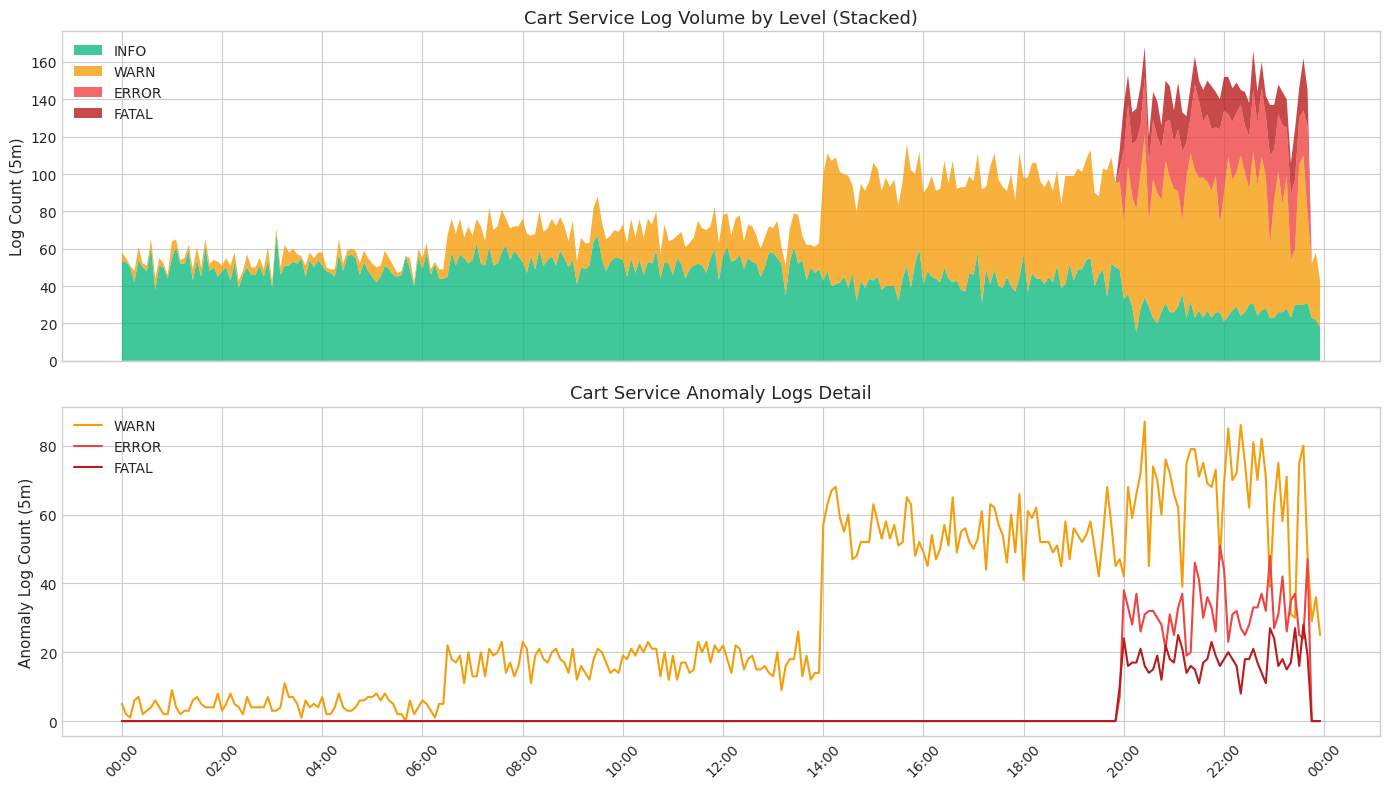

In [35]:
# 5. Plot Cart Service Logs
cart_logs_df = parse_and_bin_logs('g2/logs/cart-service.log.jsonl')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Stacked Area Plot for All Log Levels
ax1.stackplot(cart_logs_df.index, 
              cart_logs_df['INFO'], cart_logs_df['WARN'], cart_logs_df['ERROR'], cart_logs_df['FATAL'],
              labels=['INFO', 'WARN', 'ERROR', 'FATAL'],
              colors=['#10b981', '#f59e0b', '#ef4444', '#b91c1c'], alpha=0.8)
ax1.set_ylabel('Log Count (5m)')
ax1.legend(loc='upper left')
ax1.set_title('Cart Service Log Volume by Level (Stacked)')

# Line Plot for Warnings, Errors, and Fatals
ax2.plot(cart_logs_df.index, cart_logs_df['WARN'], color='#f59e0b', label='WARN')
ax2.plot(cart_logs_df.index, cart_logs_df['ERROR'], color='#ef4444', label='ERROR')
ax2.plot(cart_logs_df.index, cart_logs_df['FATAL'], color='#b91c1c', label='FATAL')
ax2.set_ylabel('Anomaly Log Count (5m)')
ax2.legend(loc='upper left')
ax2.set_title('Cart Service Anomaly Logs Detail')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

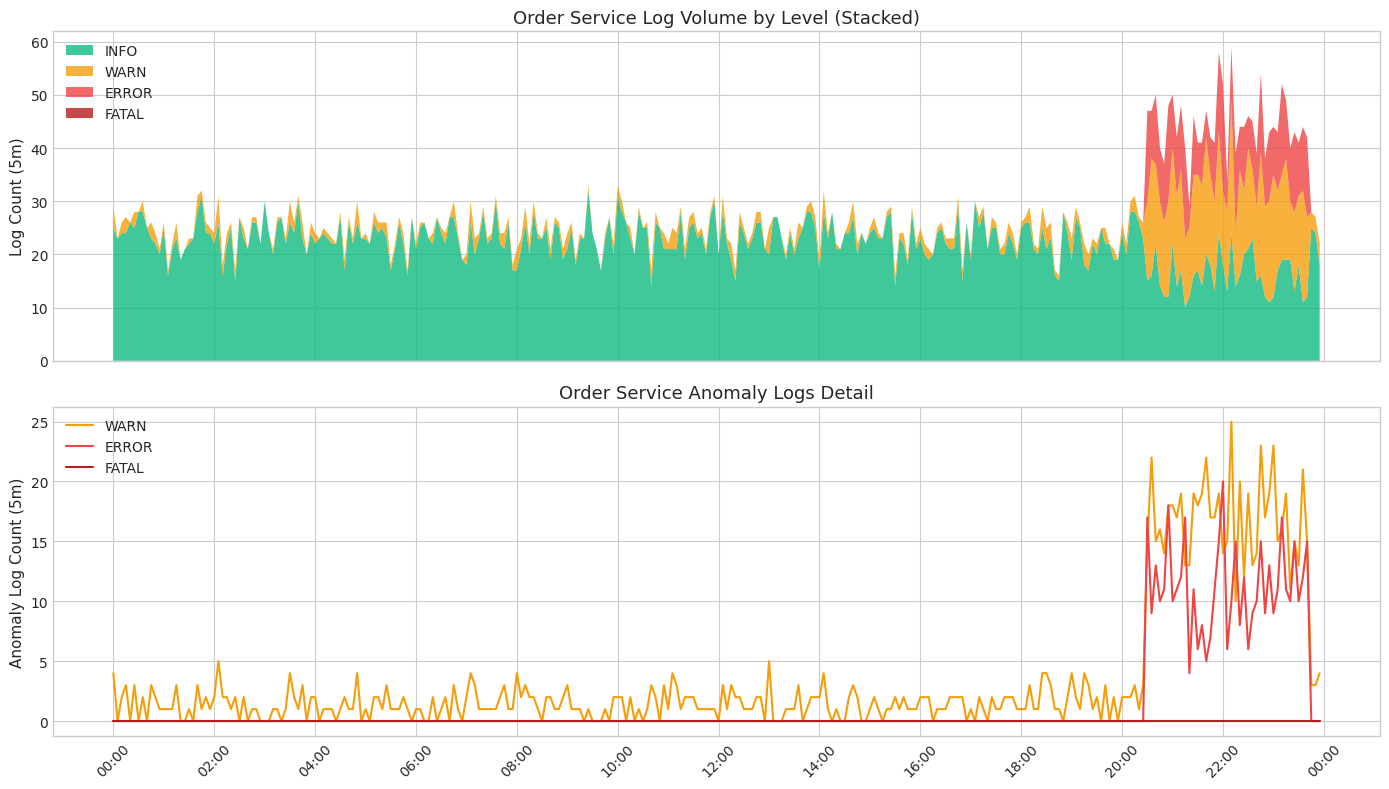

In [36]:
# 6. Plot Order Service Logs
order_logs_df = parse_and_bin_logs('g2/logs/order-service.log.jsonl')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Stacked Area Plot
ax1.stackplot(order_logs_df.index, 
              order_logs_df['INFO'], order_logs_df['WARN'], order_logs_df['ERROR'], order_logs_df['FATAL'],
              labels=['INFO', 'WARN', 'ERROR', 'FATAL'],
              colors=['#10b981', '#f59e0b', '#ef4444', '#b91c1c'], alpha=0.8)
ax1.set_ylabel('Log Count (5m)')
ax1.legend(loc='upper left')
ax1.set_title('Order Service Log Volume by Level (Stacked)')

# Line Plot for Warnings and Errors
ax2.plot(order_logs_df.index, order_logs_df['WARN'], color='#f59e0b', label='WARN')
ax2.plot(order_logs_df.index, order_logs_df['ERROR'], color='#ef4444', label='ERROR')
ax2.plot(order_logs_df.index, order_logs_df['FATAL'], color='#b91c1c', label='FATAL')
ax2.set_ylabel('Anomaly Log Count (5m)')
ax2.legend(loc='upper left')
ax2.set_title('Order Service Anomaly Logs Detail')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================================
# PART 2: MULTI-SERVICE DISTRIBUTION & NORMALITY TESTING
# =========================================================================

## 1. Distribution properties across all 5 telemetry files

In a distributed system, different metrics present different distribution models. A memory leak or resource queueing introduces heavy skewness and a Non-Gaussian profile. We evaluate the normality of primary metrics across all five microservices using **Skewness**, **Kurtosis**, and **Shapiro-Wilk test**.

In [37]:
services = {
    'api-gateway': ['http_p99_latency_ms', 'http_5xx_rate', 'cart_upstream_error_rate', 'active_connections'],
    'cart-service': ['memory_usage_bytes', 'cpu_usage_percent', 'http_p99_latency_ms', 'jvm_gc_pause_ms_avg'],
    'order-service': ['http_p99_latency_ms', 'http_5xx_rate', 'upstream_timeout_rate'],
    'payment-service': ['http_p99_latency_ms', 'http_5xx_rate', 'upstream_timeout_rate'],
    'product-service': ['http_p99_latency_ms', 'cpu_usage_percent', 'http_5xx_rate']
}

dist_results = []

for service, cols in services.items():
    df_temp = pd.read_csv(f'g2/metrics/{service}.csv')
    for col in cols:
        data = df_temp[col].dropna()
        if len(data) < 3:
            continue
        skew = data.skew()
        kurt = data.kurt()
        stat, p_val = stats.shapiro(data)
        
        dist_results.append({
            'Service': service,
            'Metric Column': col,
            'Skewness': round(skew, 2),
            'Kurtosis': round(kurt, 2),
            'Shapiro p-value': f"{p_val:.3e}",
            'Is Normal (Gaussian)': 'Yes' if p_val >= 0.05 else 'No'
        })

dist_df = pd.DataFrame(dist_results)
dist_df

,Service,Metric Column,Skewness,Kurtosis,Shapiro p-value,Is Normal (Gaussian)
0,api-gateway,http_p99_latency_ms,1.68,3.12,1.013e-48,No
1,api-gateway,http_5xx_rate,2.52,5.61,5.571e-64,No
2,api-gateway,cart_upstream_error_rate,2.83,7.00,3.109e-68,No
3,api-gateway,active_connections,0.31,-0.58,2.434e-17,No
4,cart-service,memory_usage_bytes,2.30,4.66,7.300e-59,No
5,cart-service,cpu_usage_percent,0.48,-0.34,1.537e-22,No
6,cart-service,http_p99_latency_ms,3.08,14.44,1.392e-60,No
7,cart-service,jvm_gc_pause_ms_avg,1.11,1.65,3.212e-34,No
8,order-service,http_p99_latency_ms,2.36,5.40,4.783e-58,No
9,order-service,http_5xx_rate,2.93,7.61,1.371e-68,No


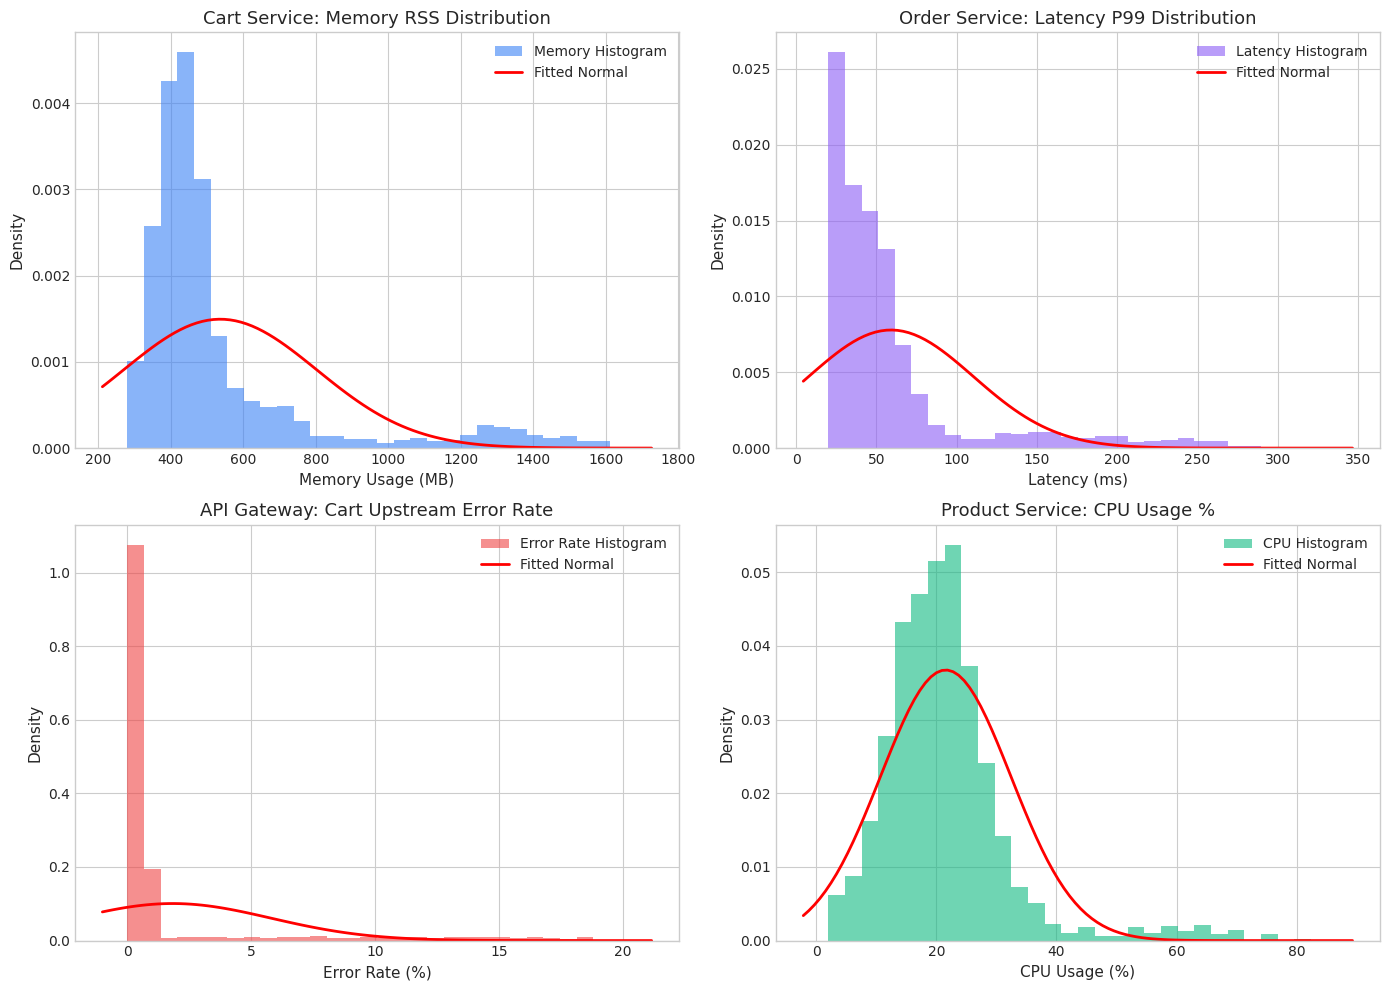

In [38]:
# 7. Grid of Histograms with Fitted Normal curves to show Non-Gaussian nature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cart Memory
axes[0,0].hist(cart_df['memory_usage_bytes']/(1024*1024), bins=30, density=True, alpha=0.6, color='#3b82f6', label='Memory Histogram')
mu, std = stats.norm.fit(cart_df['memory_usage_bytes']/(1024*1024))
xmin, xmax = axes[0,0].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[0,0].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Fitted Normal')
axes[0,0].set_title('Cart Service: Memory RSS Distribution')
axes[0,0].set_xlabel('Memory Usage (MB)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# Plot 2: Order Latency
axes[0,1].hist(order_df['http_p99_latency_ms'].dropna(), bins=30, density=True, alpha=0.6, color='#8b5cf6', label='Latency Histogram')
mu, std = stats.norm.fit(order_df['http_p99_latency_ms'].dropna())
xmin, xmax = axes[0,1].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[0,1].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Fitted Normal')
axes[0,1].set_title('Order Service: Latency P99 Distribution')
axes[0,1].set_xlabel('Latency (ms)')
axes[0,1].set_ylabel('Density')
axes[0,1].legend()

# Plot 3: API Gateway Cart Upstream Error Rate
axes[1,0].hist(api_df['cart_upstream_error_rate'].dropna(), bins=30, density=True, alpha=0.6, color='#ef4444', label='Error Rate Histogram')
mu, std = stats.norm.fit(api_df['cart_upstream_error_rate'].dropna())
xmin, xmax = axes[1,0].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[1,0].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Fitted Normal')
axes[1,0].set_title('API Gateway: Cart Upstream Error Rate')
axes[1,0].set_xlabel('Error Rate (%)')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()

# Plot 4: Product CPU Usage
axes[1,1].hist(product_df['cpu_usage_percent'].dropna(), bins=30, density=True, alpha=0.6, color='#10b981', label='CPU Histogram')
mu, std = stats.norm.fit(product_df['cpu_usage_percent'].dropna())
xmin, xmax = axes[1,1].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[1,1].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Fitted Normal')
axes[1,1].set_title('Product Service: CPU Usage %')
axes[1,1].set_xlabel('CPU Usage (%)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# =========================================================================
# PART 3: MULTI-SERVICE ANOMALY DETECTION COMPARISON
# =========================================================================

## 1. Comparing Anomaly Detection methods: Z-Score vs. Robust IQR

Because most metrics are highly skewed (Non-Gaussian), standard 3-Sigma thresholding (Z-Score) suffers from large mean shifts and fails to detect anomalies early. We compare the **Z-Score** method (threshold > 3) and the **Robust IQR** method (Q3 + 1.5*IQR) across **all 5 telemetry files** to see when anomalies are first detected and how many are flagged.

In [39]:
anomaly_results = []

for service, cols in services.items():
    df_temp = pd.read_csv(f'g2/metrics/{service}.csv')
    df_temp['timestamp'] = pd.to_datetime(df_temp['timestamp'])
    df_temp = df_temp.sort_values('timestamp')
    
    for col in cols:
        data = df_temp[col].dropna()
        if len(data) < 3:
            continue
            
        # 3-Sigma (Z-Score)
        mean = data.mean()
        std = data.std()
        z = (data - mean) / (std + 1e-9)
        z_anoms = df_temp[z > 3.0]
        z_count = len(z_anoms)
        z_earliest = z_anoms['timestamp'].iloc[0] if z_count > 0 else None
        
        # Robust IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        iqr_ub = Q3 + 1.5 * IQR
        iqr_anoms = df_temp[data > iqr_ub]
        iqr_count = len(iqr_anoms)
        iqr_earliest = iqr_anoms['timestamp'].iloc[0] if iqr_count > 0 else None
        
        anomaly_results.append({
            'Service': service,
            'Metric': col,
            'Z-Score Count': z_count,
            'Z-Score Earliest': str(z_earliest).split('+')[0] if z_earliest else 'None',
            'IQR Count': iqr_count,
            'IQR Earliest': str(iqr_earliest).split('+')[0] if iqr_earliest else 'None'
        })

anom_df = pd.DataFrame(anomaly_results)
anom_df

,Service,Metric,Z-Score Count,Z-Score Earliest,IQR Count,IQR Earliest
0,api-gateway,http_p99_latency_ms,67,2026-06-01 22:01:30,135,2026-06-01 20:43:30
1,api-gateway,http_5xx_rate,110,2026-06-01 22:12:30,363,2026-06-01 20:11:00
2,api-gateway,cart_upstream_error_rate,121,2026-06-01 22:21:30,413,2026-06-01 20:00:30
3,api-gateway,active_connections,1,2026-06-01 20:05:00,1,2026-06-01 20:05:00
4,cart-service,memory_usage_bytes,103,2026-06-01 18:53:00,350,2026-06-01 16:43:30
5,cart-service,cpu_usage_percent,0,None,5,2026-06-01 20:46:00
6,cart-service,http_p99_latency_ms,43,2026-06-01 19:58:30,61,2026-06-01 19:58:30
7,cart-service,jvm_gc_pause_ms_avg,39,2026-06-01 18:04:30,157,2026-06-01 16:28:30
8,order-service,http_p99_latency_ms,93,2026-06-01 21:49:30,325,2026-06-01 16:49:30
9,order-service,http_5xx_rate,123,2026-06-01 22:14:30,383,2026-06-01 20:30:30


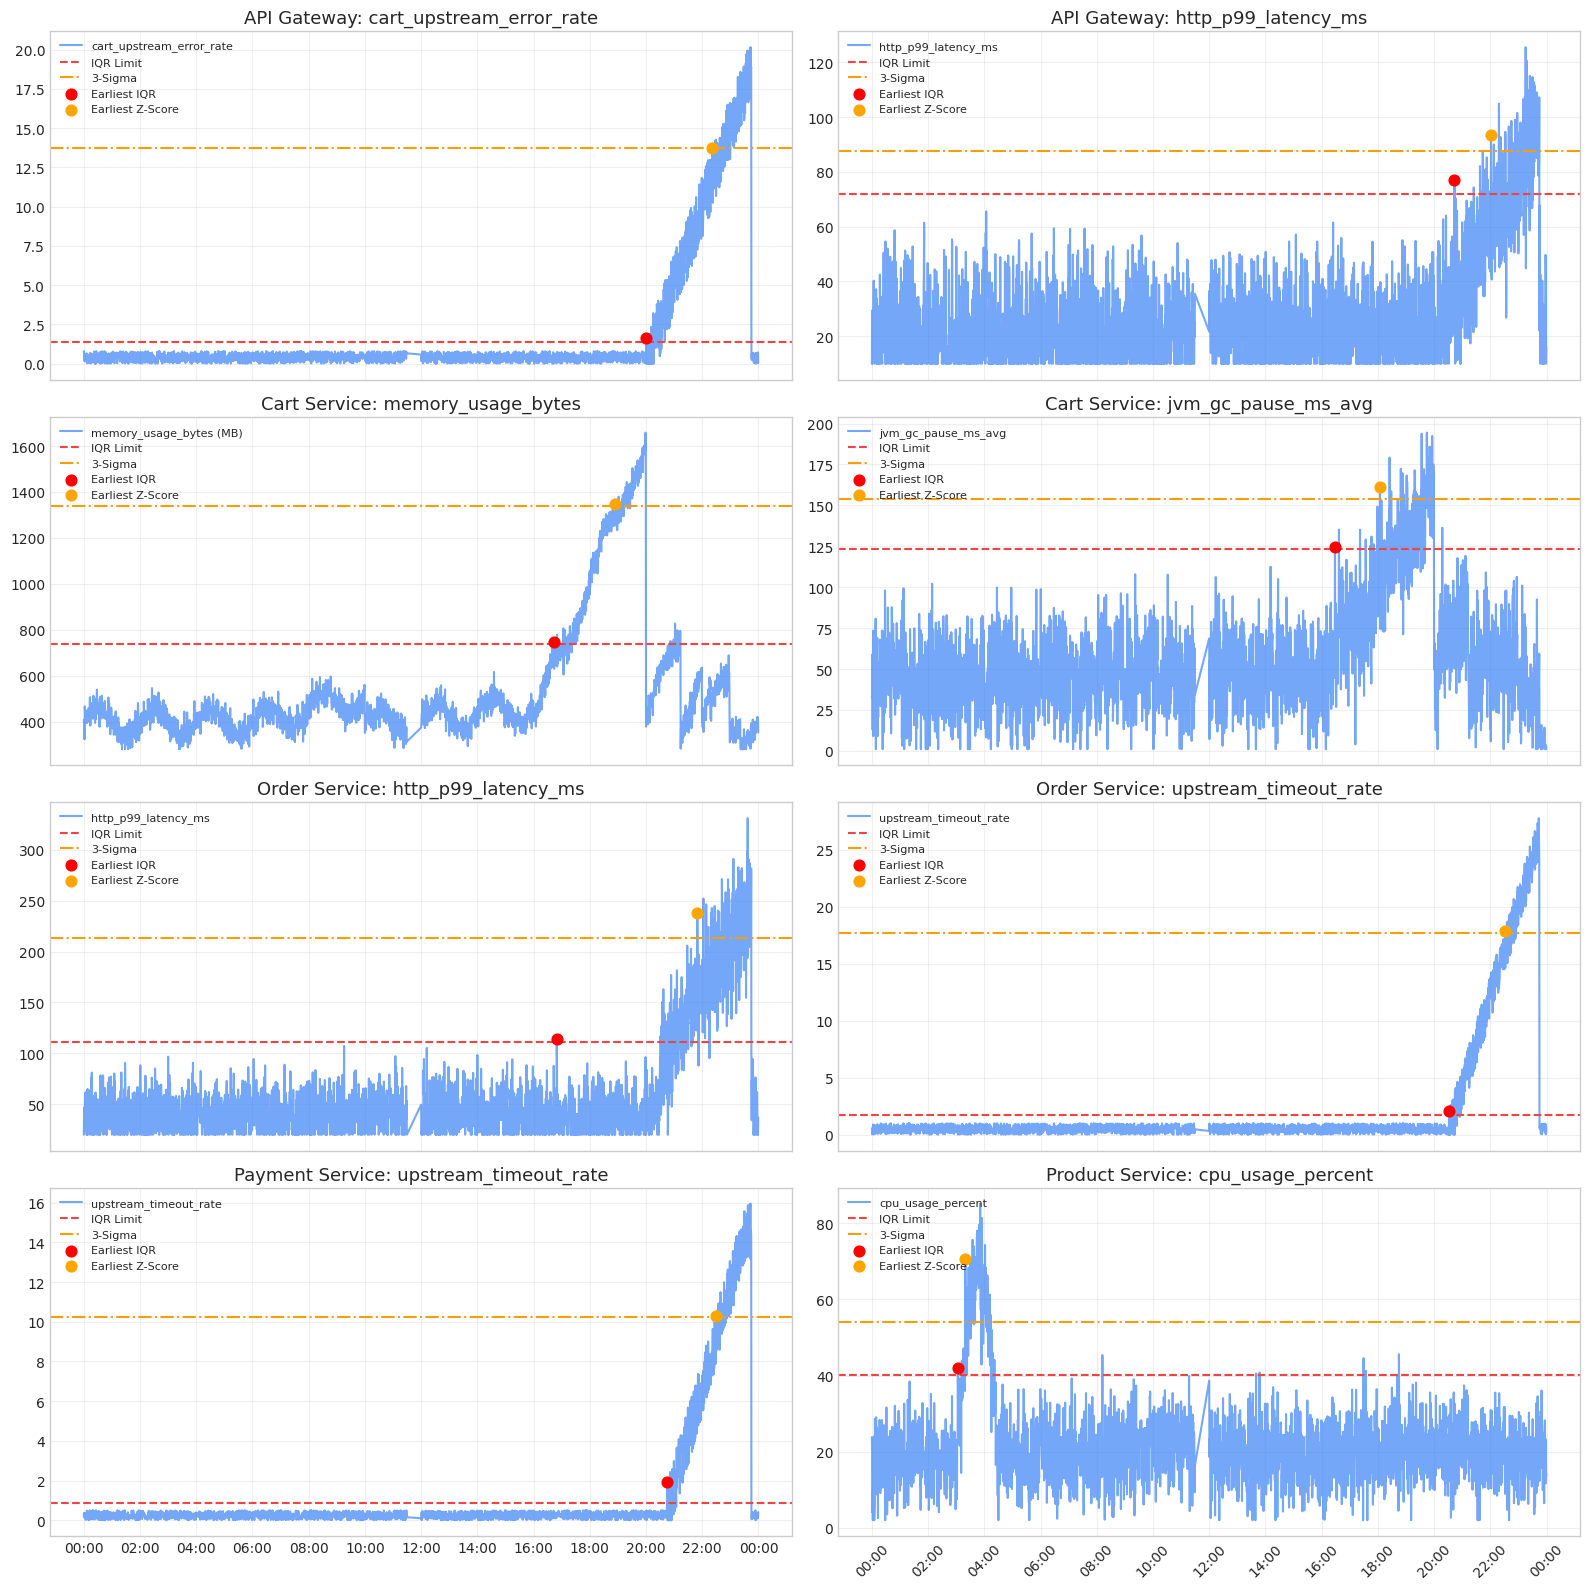

In [40]:
# 8. Anomaly detection plots for each CSV file showing thresholds and earliest anomaly markers
def plot_anomalies_for_metric(df, col_name, service_name, ax):
    data = df[col_name].dropna()
    mean = data.mean()
    std = data.std()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_ub = Q3 + 1.5 * IQR
    
    z = (data - mean) / (std + 1e-9)
    z_anoms = df[z > 3.0]
    iqr_anoms = df[df[col_name] > iqr_ub]
    
    y_data = df[col_name]
    unit = ""
    # Check if we should scale bytes to MB for memory column
    if 'bytes' in col_name:
        y_data = y_data / (1024*1024)
        mean /= (1024*1024)
        std /= (1024*1024)
        iqr_ub /= (1024*1024)
        unit = " (MB)"
        
    ax.plot(df['timestamp'], y_data, color='#3b82f6', alpha=0.7, label=f'{col_name}{unit}')
    ax.axhline(y=iqr_ub, color='#ef4444', linestyle='--', label='IQR Limit')
    ax.axhline(y=mean + 3*std, color='#f59e0b', linestyle='-.', label='3-Sigma')
    
    if not iqr_anoms.empty:
        val = iqr_anoms[col_name].iloc[0] / (1024*1024) if 'bytes' in col_name else iqr_anoms[col_name].iloc[0]
        ax.scatter(iqr_anoms['timestamp'].iloc[0], val, color='red', s=60, zorder=5, label='Earliest IQR')
    if not z_anoms.empty:
        val = z_anoms[col_name].iloc[0] / (1024*1024) if 'bytes' in col_name else z_anoms[col_name].iloc[0]
        ax.scatter(z_anoms['timestamp'].iloc[0], val, color='orange', s=60, zorder=5, label='Earliest Z-Score')
        
    ax.set_title(f'{service_name}: {col_name}')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharex=True)
plot_anomalies_for_metric(api_df, 'cart_upstream_error_rate', 'API Gateway', axes[0, 0])
plot_anomalies_for_metric(api_df, 'http_p99_latency_ms', 'API Gateway', axes[0, 1])
plot_anomalies_for_metric(cart_df, 'memory_usage_bytes', 'Cart Service', axes[1, 0])
plot_anomalies_for_metric(cart_df, 'jvm_gc_pause_ms_avg', 'Cart Service', axes[1, 1])
plot_anomalies_for_metric(order_df, 'http_p99_latency_ms', 'Order Service', axes[2, 0])
plot_anomalies_for_metric(order_df, 'upstream_timeout_rate', 'Order Service', axes[2, 1])
plot_anomalies_for_metric(payment_df, 'upstream_timeout_rate', 'Payment Service', axes[3, 0])
plot_anomalies_for_metric(product_df, 'cpu_usage_percent', 'Product Service', axes[3, 1])

axes[3, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[3, 0].xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================================
# PART 4: CART SERVICE FEATURE ENGINEERING & ISOLATION FOREST
# =========================================================================

Isolation Forest detected 141 anomalous windows.
  Earliest Anomaly: 2026-06-01 16:37:00+00:00 | Memory: 687.19 MB | GC/Req: 3.769


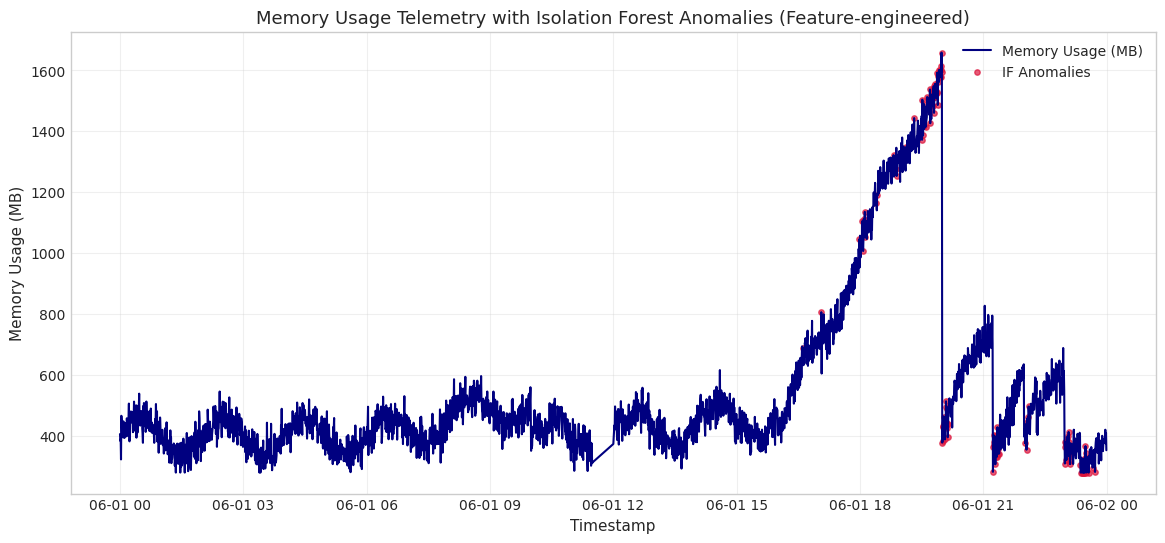

In [41]:
df_feat = cart_df.copy()

# Construct engineered features
df_feat['gc_per_req'] = df_feat['jvm_gc_pause_ms_avg'] / (df_feat['http_requests_per_sec'] + 0.1)
df_feat['mem_util_ratio'] = df_feat['memory_usage_bytes'] / df_feat['memory_limit_bytes']
df_feat['mem_growth_rate_30s'] = df_feat['memory_usage_bytes'].diff().fillna(0)
df_feat['mem_rolling_std_10m'] = df_feat['memory_usage_bytes'].rolling(window=20, min_periods=1).std().fillna(0)
df_feat['latency_rolling_mean_10m'] = df_feat['http_p99_latency_ms'].rolling(window=20, min_periods=1).mean()

features = [
    'memory_usage_bytes', 
    'mem_growth_rate_30s', 
    'mem_util_ratio', 
    'gc_per_req', 
    'mem_rolling_std_10m', 
    'latency_rolling_mean_10m'
]

clean_df = df_feat.dropna(subset=features).copy()
X = clean_df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest (contamination = 5%)
clf = IsolationForest(contamination=0.05, random_state=42)
clean_df['anomaly'] = clf.fit_predict(X_scaled)

if_anoms = clean_df[clean_df['anomaly'] == -1]
print(f"Isolation Forest detected {len(if_anoms)} anomalous windows.")
if not if_anoms.empty:
    earliest_if = if_anoms.iloc[0]
    print(f"  Earliest Anomaly: {earliest_if['timestamp']} | Memory: {earliest_if['memory_usage_bytes']/(1024*1024):.2f} MB | GC/Req: {earliest_if['gc_per_req']:.3f}")

# Plot Memory Usage over time highlighting all Isolation Forest anomalies
plt.figure(figsize=(14, 6))
plt.plot(clean_df['timestamp'], clean_df['memory_usage_bytes'] / (1024*1024), color='navy', label='Memory Usage (MB)')
plt.scatter(if_anoms['timestamp'], if_anoms['memory_usage_bytes']/(1024*1024), color='crimson', s=15, alpha=0.7, label='IF Anomalies')

plt.title('Memory Usage Telemetry with Isolation Forest Anomalies (Feature-engineered)')
plt.xlabel('Timestamp')
plt.ylabel('Memory Usage (MB)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

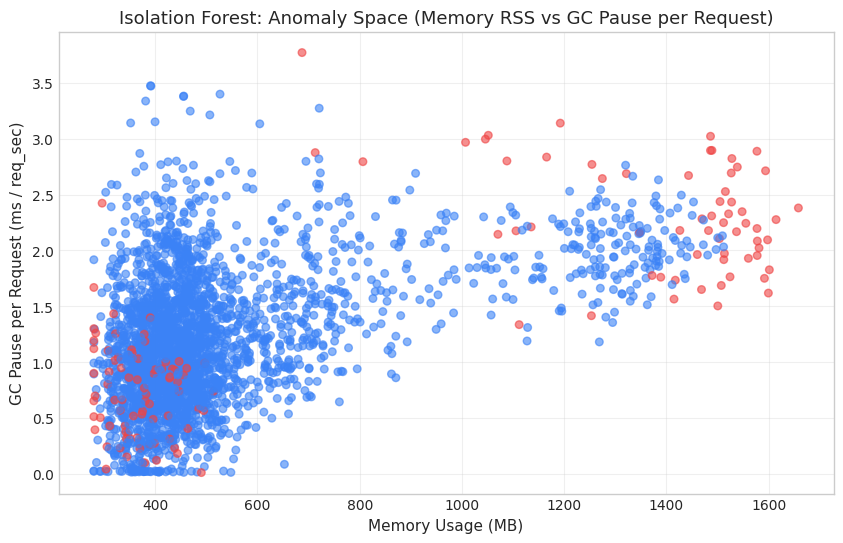

In [42]:
# 9. Multi-Dimensional Anomaly Space Scatter Plot (Memory RSS vs GC Pauses / Request)
plt.figure(figsize=(10, 6))
colors = clean_df['anomaly'].map({1: '#3b82f6', -1: '#ef4444'})
plt.scatter(clean_df['memory_usage_bytes']/(1024*1024), clean_df['gc_per_req'], c=colors, alpha=0.6, s=30)
plt.title('Isolation Forest: Anomaly Space (Memory RSS vs GC Pause per Request)')
plt.xlabel('Memory Usage (MB)')
plt.ylabel('GC Pause per Request (ms / req_sec)')
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================================
# PART 5: LOG DIAGNOSTICS & CASCADE CORRELATION
# =========================================================================

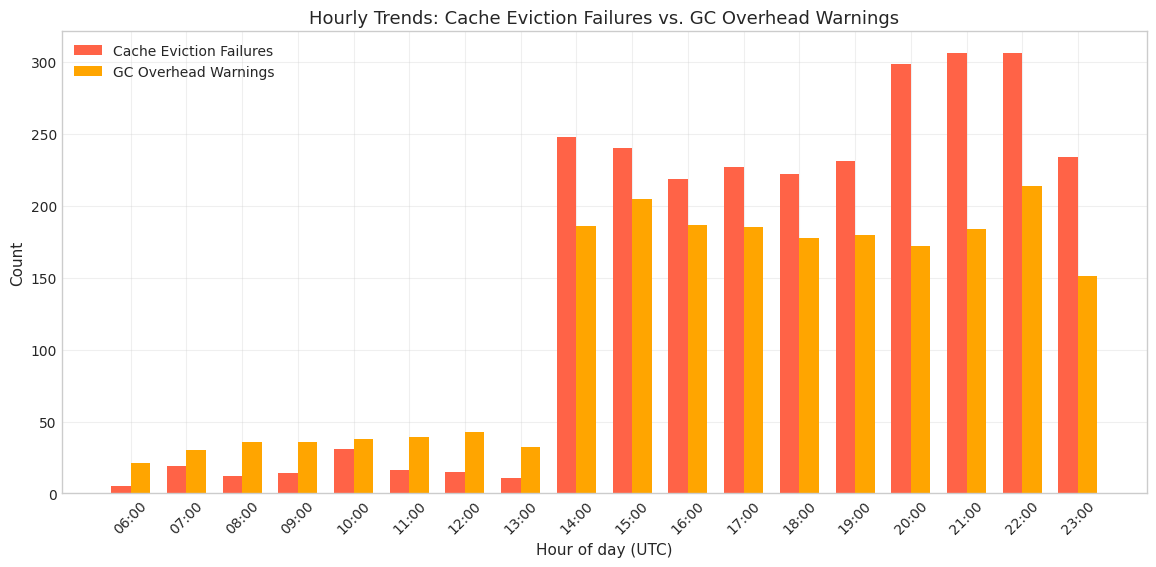

=== Earliest Event Timestamps in Logs ===
Earliest GC Overhead Warning:  2026-06-01T06:30:19.395Z
Earliest Cache Eviction Fail  :  2026-06-01T06:32:33.431Z
Earliest Container OOMKilled  :  2026-06-01T19:59:02.158Z


In [43]:
eviction_hourly = {}
gc_hourly = {}
cart_log_path = 'g2/logs/cart-service.log.jsonl'

with open(cart_log_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            log = json.loads(line)
            ts = pd.to_datetime(log['timestamp'])
            hour = ts.strftime('%Y-%m-%d %H:00:00')
            msg = log.get('message', '')
            
            if "eviction failed" in msg.lower():
                eviction_hourly[hour] = eviction_hourly.get(hour, 0) + 1
            if "gc overhead" in msg.lower():
                gc_hourly[hour] = gc_hourly.get(hour, 0) + 1
        except:
            pass

# Merge hourly counts
hours = sorted(list(set(eviction_hourly.keys()) | set(gc_hourly.keys())))
eviction_counts = [eviction_hourly.get(h, 0) for h in hours]
gc_counts = [gc_hourly.get(h, 0) for h in hours]

# Plot trends hourly
x = np.arange(len(hours))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, eviction_counts, width, label='Cache Eviction Failures', color='tomato')
plt.bar(x + width/2, gc_counts, width, label='GC Overhead Warnings', color='orange')

plt.xticks(x, [h.split()[1][:5] for h in hours], rotation=45)
plt.title('Hourly Trends: Cache Eviction Failures vs. GC Overhead Warnings')
plt.xlabel('Hour of day (UTC)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Earliest timestamps
first_evict, first_gc, first_oom = None, None, None
with open(cart_log_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            obj = json.loads(line)
            msg = obj.get('message', '')
            ts = obj.get('timestamp')
            if 'eviction failed' in msg.lower() and not first_evict:
                first_evict = ts
            if 'gc overhead' in msg.lower() and not first_gc:
                first_gc = ts
            if 'oomkilled' in msg.lower() and not first_oom:
                first_oom = ts
        except:
            pass

print("=== Earliest Event Timestamps in Logs ===")
print("Earliest GC Overhead Warning: ", first_gc)
print("Earliest Cache Eviction Fail  : ", first_evict)
print("Earliest Container OOMKilled  : ", first_oom)

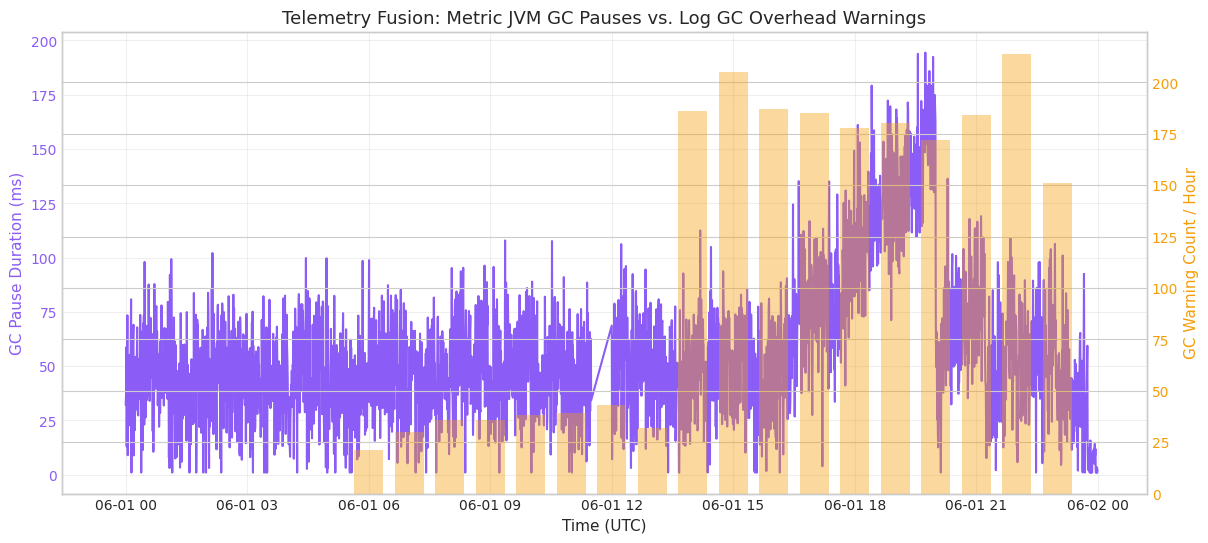

In [44]:
# 10. Telemetry Fusion: Metric JVM GC Pauses (left axis) vs. Logs GC Warnings (right axis)
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(cart_df['timestamp'], cart_df['jvm_gc_pause_ms_avg'], color=METRIC_COLORS['purple'], linewidth=1.5, label='Metric: GC Pause Avg (ms)')
ax1.set_xlabel('Time (UTC)')
ax1.set_ylabel('GC Pause Duration (ms)', color=METRIC_COLORS['purple'])
ax1.tick_params(axis='y', labelcolor=METRIC_COLORS['purple'])
ax1.grid(True, alpha=0.3)

# Build hourly log warnings
gc_log_times = []
with open(cart_log_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            log = json.loads(line)
            if 'gc overhead' in log.get('message', '').lower():
                gc_log_times.append(pd.to_datetime(log['timestamp']))
        except:
            pass

gc_log_series = pd.Series(1, index=gc_log_times)
gc_log_hourly = gc_log_series.resample('1h').sum().reindex(
    pd.date_range(cart_df['timestamp'].min(), cart_df['timestamp'].max(), freq='1h'), fill_value=0
)

ax2 = ax1.twinx()
ax2.bar(gc_log_hourly.index, gc_log_hourly.values, width=0.03, alpha=0.4, color=METRIC_COLORS['orange'], label='Logs: Hourly GC Warnings')
ax2.set_ylabel('GC Warning Count / Hour', color=METRIC_COLORS['orange'])
ax2.tick_params(axis='y', labelcolor=METRIC_COLORS['orange'])

plt.title('Telemetry Fusion: Metric JVM GC Pauses vs. Log GC Overhead Warnings')
plt.show()

In [45]:
order_log_path = 'g2/logs/order-service.log.jsonl'

order_tids = set()
with open(order_log_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            log = json.loads(line)
            if 'trace_id' in log and log['trace_id'] != '0':
                order_tids.add(log['trace_id'])
        except:
            pass

cart_tids = set()
with open(cart_log_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            log = json.loads(line)
            if 'trace_id' in log and log['trace_id'] != '0':
                cart_tids.add(log['trace_id'])
        except:
            pass

intersection = order_tids.intersection(cart_tids)
print(f"Total unique traces in order-service: {len(order_tids)}")
print(f"Total unique traces in cart-service : {len(cart_tids)}")
print(f"Intersection (Shared traces)        : {len(intersection)}")

if len(intersection) == 0:
    print("\n>> WARNING: Distributed Trace IDs do NOT overlap! Context propagation is broken.")

Total unique traces in order-service: 7857
Total unique traces in cart-service : 24275
Intersection (Shared traces)        : 0

>> WARNING: Distributed Trace IDs do NOT overlap! Context propagation is broken.


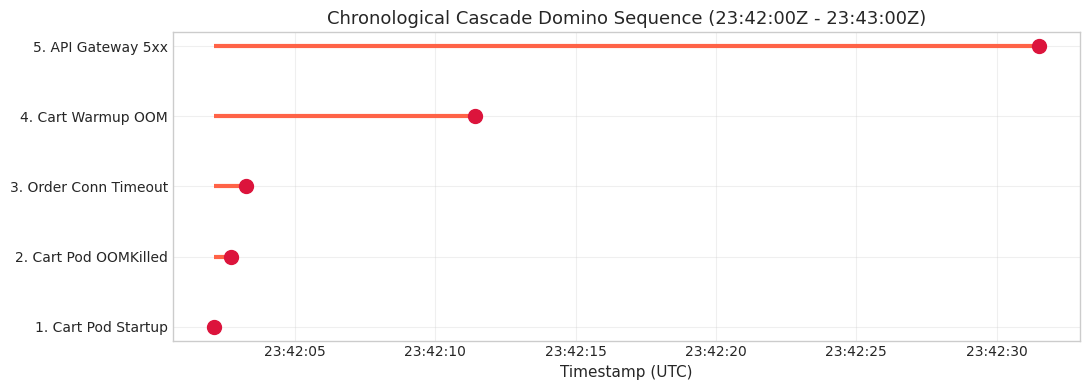

In [46]:
# 11. Domino Cascade Sequence Timeline Step Plot (23:42:00Z - 23:43:00Z)
event_times = [
    pd.to_datetime('2026-06-01 23:42:02.139'),
    pd.to_datetime('2026-06-01 23:42:02.746'),
    pd.to_datetime('2026-06-01 23:42:03.271'),
    pd.to_datetime('2026-06-01 23:42:11.437'),
    pd.to_datetime('2026-06-01 23:42:31.496')
]
labels = [
    '1. Cart Pod Startup',
    '2. Cart Pod OOMKilled',
    '3. Order Conn Timeout',
    '4. Cart Warmup OOM',
    '5. API Gateway 5xx'
]

plt.figure(figsize=(11, 4))
plt.hlines(y=labels, xmin=min(event_times), xmax=event_times, color='tomato', linewidth=3)
plt.plot(event_times, labels, 'o', color='crimson', markersize=10)
plt.title('Chronological Cascade Domino Sequence (23:42:00Z - 23:43:00Z)')
plt.xlabel('Timestamp (UTC)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
cart_events = []
with open(cart_log_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            log = json.loads(line)
            ts = log['timestamp']
            if '2026-06-01T23:42:' in ts or '2026-06-01T23:43:' in ts or '2026-06-01T23:44:' in ts:
                cart_events.append((ts, 'cart-service', log['level'], log['message']))
        except:
            pass

order_events = []
with open(order_log_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            log = json.loads(line)
            ts = log['timestamp']
            if '2026-06-01T23:42:' in ts or '2026-06-01T23:43:' in ts or '2026-06-01T23:44:' in ts:
                order_events.append((ts, 'order-service', log['level'], log['message']))
        except:
            pass

merged_timeline = sorted(cart_events + order_events, key=lambda x: x[0])

print("=== Temporal Cascade Log Timeline (23:42:00Z - 23:44:30Z) ===")
displayed = 0
for ts, service, level, msg in merged_timeline:
    is_relevant = (level in ['WARN', 'ERROR', 'FATAL'] or 
                   'starting' in msg.lower() or 
                   'succeeded' in msg.lower() or 
                   'oomkilled' in msg.lower())
    if is_relevant and displayed < 30:
        short_ts = ts.split('T')[1].replace('Z', '')
        print(f"[{short_ts}] [{service:13}] | {level:5} | {msg}")
        displayed += 1

=== Temporal Cascade Log Timeline (23:42:00Z - 23:44:30Z) ===
[23:42:02.139] [cart-service ] | INFO  | Application starting up version=2.4.1
[23:42:02.746] [cart-service ] | FATAL | Container OOMKilled: memory limit exceeded
[23:42:03.271] [order-service] | WARN  | Cart service timeout after 2782ms
[23:42:03.299] [cart-service ] | INFO  | Application starting up version=2.4.1
[23:42:03.416] [cart-service ] | ERROR | OutOfMemoryError imminent: available heap < 5%
[23:42:06.093] [cart-service ] | INFO  | Application starting up version=2.4.1
[23:42:06.708] [cart-service ] | INFO  | Application starting up version=2.4.1
[23:42:08.655] [cart-service ] | ERROR | Upstream connection refused host=product-service
[23:42:11.437] [cart-service ] | FATAL | Container OOMKilled: memory limit exceeded
[23:42:12.354] [cart-service ] | ERROR | OutOfMemoryError imminent: available heap < 5%
[23:42:12.952] [cart-service ] | ERROR | OutOfMemoryError imminent: available heap < 5%
[23:42:14.351] [cart-serv

# =========================================================================
# PART 6: ROOT CAUSE ANALYSIS (RCA) & REMEDIATION PLAN
# =========================================================================

## 1. Root Cause Hypothesis (WHAT)

- **The Bug: Memory Leak in cache (`ProductCatalogCache`)**
  - The `cart-service` periodically performs cache warm-up (every 3 minutes, ~19 times/hour) loading 8,000 to 25,000 entries. 
  - Due to heap pressure, eviction fails (`ProductCatalogCache eviction failed: heap pressure too high`), creating a **vicious cycle**: higher heap -> eviction skipped -> heap increases further.
- **JVM Heap vs Kubernetes Container Limit**
  - Container RSS limit is 2GB. Since JVM heap maximum (`-Xmx`) was not correctly restricted, RSS memory kept growing until K8s sent SIGKILL (OOMKilled).

## 2. Mechanism of the Restart Loop

- When the pod restarts, it initiates a **cache warm-up** during initialization, loading a massive amount of data.
- Simultaneously, backlogged user traffic from dead pods pours in (**Thundering Herd**).
- This dual memory consumption causes the container RSS to exceed the 2GB limit within seconds, crashing it again before reaching `Ready` status.

## 3. Remediation Actions

1. **Set explicit JVM Heap limit**: Configure `-Xmx1400m` to ensure JVM heap remains below the container limit, leaving 600MB for thread stack and off-heap allocations.
2. **Fix Eviction logic**: Eviction must not be skipped under heap pressure; instead, eviction should be *more* aggressive when heap pressure is high.
3. **Throttling during Initialization**: Implement rate-limiting on warm-up queries and delay routing traffic until readiness probes succeed.
4. **Fix Distributed Tracing**: Enable W3C tracecontext header propagation in OpenTelemetry/APM configurations between microservices.